In [1]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
tf.test.is_gpu_available()

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!unzip /content/drive/MyDrive/cats_and_dogs_filtered.zip

Archive:  /content/drive/MyDrive/cats_and_dogs_filtered.zip
   creating: cats_and_dogs_filtered/
  inflating: cats_and_dogs_filtered/.DS_Store  
   creating: cats_and_dogs_filtered/test/
   creating: cats_and_dogs_filtered/train/
   creating: cats_and_dogs_filtered/test/dogs/
   creating: cats_and_dogs_filtered/test/cats/
  inflating: cats_and_dogs_filtered/test/.DS_Store  
   creating: cats_and_dogs_filtered/train/dogs/
   creating: cats_and_dogs_filtered/train/cats/
  inflating: cats_and_dogs_filtered/train/.DS_Store  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2448.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2460.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2461.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2449.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2463.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2462.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/dog.2466.jpg  
  inflating: cats_and_dogs_filtered/test/dogs/

In [5]:
root_dir = r"/content/cats_and_dogs_filtered"

In [6]:
BATCH_SIZE  = 64
EPOCHS = 100
input_img_size = (128,128)
input_shape = (128,128,3)

In [7]:
# tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     horizontal_flip=True,
#     validation_split=0.2,
#     rescale=1./255,
#     rotation_range=25,
#     zoom_range=0.2,
#     brightness_range=[0.8, 1.2]
# )

# tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     horizontal_flip=True,
#     vertical_flip=True,
#     zoom_range=1.0,
#     rescale=1/255.0,
#     rotation_range=25,
#     brightness_range=[0.8, 1.2]
# )

tf_generator =  tf.keras.preprocessing.image.ImageDataGenerator(
      rescale=1./255,
      rotation_range=20,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest'
)

In [8]:
# train_ds = tf.keras.utils.image_dataset_from_directory(
#     root_dir,
#     validation_split=0.2,
#     subset="training",
#     seed=42,
#     image_size=input_img_size,
#     batch_size=BATCH_SIZE,
#     label_mode="binary"
# )
# val_ds = tf.keras.utils.image_dataset_from_directory(
#     root_dir,
#     validation_split=0.2,
#     subset="validation",
#     seed=42,
#     image_size=input_img_size,
#     batch_size=BATCH_SIZE,
#     label_mode="binary"
# )

train_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir+"/train",
    shuffle=True,
    image_size=input_img_size,
    batch_size=BATCH_SIZE,
    label_mode='categorical'  # or 'categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    root_dir+"/test",
    shuffle=True,
    image_size=input_img_size,
    batch_size=BATCH_SIZE,
    label_mode='categorical'  # or 'categorical'
)

Found 2752 files belonging to 2 classes.
Found 248 files belonging to 2 classes.


In [9]:
# for images, labels in train_ds.take(1):
#     plt.figure(figsize=(5,5))
#     plt.imshow(images[0].numpy() / 255.)  # normalize if not already
#     plt.title(f"Label: {int(labels[0])}")
#     plt.axis('off')
#     plt.show()
#     break

In [ ]:
# Normalize
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(lambda x, y: (x/255.0, y)).cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (x/255.0, y)).cache().prefetch(AUTOTUNE)

In [10]:
# import tensorflow
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D,Dense,Flatten,MaxPooling2D

# model = Sequential([
#     Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
#     MaxPooling2D((2,2)),
#     Conv2D(64,(3,3),activation="relu"),
#     Conv2D(64,(3,3),activation="relu"),
#     MaxPooling2D((2,2)),
#     Flatten(),
#     Dense(256,activation="relu"),
#     Dense(128,activation="relu"),
#     Dense(1,activation='sigmoid')
# ])

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# model = Sequential([
#     # Increase filters and add another convolutional block
#     Conv2D(64, (3, 3), activation='relu', input_shape=input_shape),
#     MaxPooling2D((2, 2)),
#     Conv2D(128, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),
#     Conv2D(256, (3, 3), activation='relu'),
#     MaxPooling2D((2, 2)),

#     Flatten(),

#     # Increase neurons in dense layers
#     Dense(512, activation='relu'),
#     Dense(256, activation='relu'),

#     Dense(1, activation='sigmoid')
# ])

# model = Sequential([
#     Conv2D(32,(3,3),activation="relu",input_shape=input_shape),
#     MaxPooling2D((2,2)),
#     Conv2D(64,(3,3),activation="relu"),
#     Conv2D(64,(3,3),activation="relu"),
#     MaxPooling2D((2,2)),
#     Flatten(),
#     Dense(256,activation="relu"),
#     Dense(128,activation="relu"),
#     Dense(1,activation='softmax')


# ])

# model = Sequential([
#     Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),
#     Dropout(0.3),
#     Conv2D(64, (3,3), activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),
#     Dropout(0.1),
#     Conv2D(64, (3,3), activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),
#     Dropout(0.2),
#     Conv2D(64, (3,3), activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),
#     Dropout(0.3),
#     Flatten(),
#     Dense(256,activation="relu"),
#     BatchNormalization(),
#     Dropout(0.2),
#     Dense(126, activation="sigmoid")
# ])

model = Sequential([
    Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),

    Conv2D(256, (3, 3), padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2), strides=2),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(2, activation='sigmoid')
])

# model = Sequential([
#     Conv2D(32, (3,3), padding="same", strides=2, activation="relu",input_shape=input_shape),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),

#     Conv2D(64, (3,3), padding="same", strides=2, activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),

#     Conv2D(128, (3,3), padding="same", strides=2, activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),

#     Conv2D(256, (3,3), padding="same", strides=2, activation="relu"),
#     BatchNormalization(),
#     MaxPooling2D((2,2)),

#     Flatten(),
#     Dense(512, activation="relu"),
#     Dropout(0.2),
#     Dense(128, activation="relu"),
#     Dropout(0.3),
#     Dense(2, activation="sigmoid"),

# ])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
from tensorflow.keras.optimizers import Adam
model.compile(loss='binary_crossentropy',
              optimizer = Adam(learning_rate=0.001),
              metrics = ['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,618,050 (17.62 MB)

 Trainable params: 4,617,090 (17.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [12]:
# early_stop = EarlyStopping(
#     monitor='val_loss',
#     patience=5,
#     restore_best_weights=True
# )

# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# history = model.fit(train_ds,epochs=EPOCHS, validation_data=val_ds,verbose=1)
# model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=[early_stopping])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(train_ds,
                    epochs=EPOCHS,
                    validation_data=val_ds,
                    callbacks=[early_stopping],
                    verbose=1,)

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.5586 - loss: 2.2249 - val_accuracy: 0.4758 - val_loss: 1.8835
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.5563 - loss: 1.0258 - val_accuracy: 0.5403 - val_loss: 0.7027
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.6132 - loss: 0.7170 - val_accuracy: 0.5645 - val_loss: 0.6837
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6012 - loss: 0.6519 - val_accuracy: 0.6371 - val_loss: 0.6506
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.6258 - loss: 0.6293 - val_accuracy: 0.6210 - val_loss: 0.6743
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.6178 - loss: 0.6244 - val_accuracy: 0.6250 - val_loss: 0.6394
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6521 - loss: 0.6288 - val_accuracy: 0.5766 - val_loss: 0.6658
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6827 - loss: 0.5816 - val_accuracy: 

In [15]:
loss, accuracy = model.evaluate(val_ds)
# train_loss, train_accuracy = model.evaluate(train_ds)

# print(f"Loss: {loss:.2f}")
# print(f"Accuracy: {accuracy:.2f}")

print(f"Validation Loss: {loss:.2f}")
print(f"Validation Accuracy: {accuracy:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7314 - loss: 0.5639
Validation Loss: 0.57
Validation Accuracy: 0.72


In [16]:
BATCH_SIZE
input_shape

(128, 128, 3)

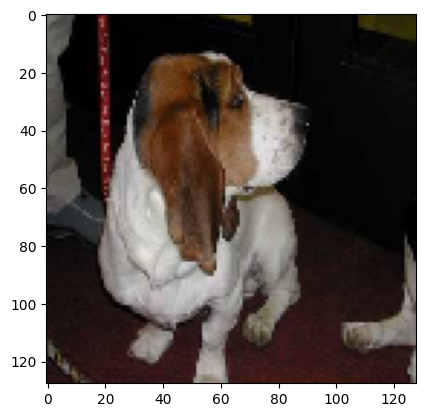

In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"/content/cats_and_dogs_filtered/test/dogs/dog.2377.jpg"

img = image.load_img(img_path, target_size=input_img_size)
img_array = image.img_to_array(img)  # shape: (_, _, 3)
img_array = img_array / 255.0        # normalize

img_array = np.expand_dims(img_array, axis=0)  # shape: (1, _, _, 3)
plt.imshow(img_array[0])  # Display the image

In [18]:
class_names = train_ds.class_names

# Convert to dict
class_indices = {name: idx for idx, name in enumerate(class_names)}
print("Class names found:", class_indices)

Class names found: {'cats': 0, 'dogs': 1}


In [19]:
class_names

['cats', 'dogs']

In [20]:
model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 931ms/step


np.float32(0.8990223)

In [21]:
prediction = model.predict(img_array)[0][0]
class_name = "dogs" if prediction > 0.5 else "cats"

print(f"Predicted class: {class_name} with confidence {prediction:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted class: dogs with confidence 0.90


### Model Saving

In [23]:
!pip install python-dotenv

In [25]:
import os
from dotenv import load_dotenv
load_dotenv()

ML_Summer_School_ID = os.getenv('ML_Summer_School_ID')
print("Your Sudent ID is: " + ML_Summer_School_ID)

In [26]:
model.save(f'./binary_classification/ML040_KaungKhant_model.h5')

In [27]:
import json
# Save class names to a text file
with open(f'./binary_classification/ML040_KaungKhant_class_indices.json', 'w') as f:
    class_names = train_ds.class_names

    # Convert to dict
    class_indices = {name: idx for idx, name in enumerate(class_names)}
    json.dump(class_indices, f)
